# Ciclo de mudança de conceito — equipamento B-4064A

Detectar → quarentena → recalibrar → continuar monitorando, simulado sobre 20 meses do B-4064A
(código em `src/transpetro_modelos/drift/ciclo.py`).

**Por que o ciclo:** no teste isolado do detector (`detector_ks_calibrado_B-8802B_B-4064A.ipynb`) a
referência nunca é atualizada. Depois do reparo, cada dia continua sendo comparado com o normal de
antes, e o detector redetecta a mesma mudança todo dia. O ciclo fecha esse laço.

**As fases**
1. **Monitorando**: o detector (KS calibrado, janela de 1 dia, 3 de 5 dias) compara cada dia com a referência.
2. **Detecção**: registra quando e por qual sensor, e entra em quarentena.
3. **Quarentena (30 dias)**: coleta o comportamento novo sem disparar. Em produção, é aqui que a operação
   confirma se é um novo normal (manutenção, regime) ou degradação. A simulação assume novo normal.
4. **Recalibração e maturação**: a referência passa a ser o dado desde a detecção e é refeita a cada 30 dias
   com tudo o que foi acumulado, até cobrir 12 meses. Um disparo nessa fase não é conceito novo: significa
   que a referência ainda não cobre a variação do novo normal, e a recalibração é antecipada.
5. Com a referência madura (12 meses), ela fica fixa até a próxima detecção.

Parada longa (mais de 3 dias sem operação) zera a contagem de persistência.

**Eventos conhecidos do B-4064A:** falha em 30/08/2024 (rampa de ~2 dias) e volta do reparo em
14/01/2025, com o mancal LNA operando ~20 °C acima (novo normal confirmado pela operação).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing
from transpetro_modelos.drift.detectors import CalibratedKSDetector
from transpetro_modelos.drift.ciclo import simular_ciclo

raw = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-4064A_novos.feather")
if "Timestamp" in raw.columns: raw = raw.set_index("Timestamp"); raw.index = pd.to_datetime(raw.index)
serie, _, _ = run_preprocessing(raw.sort_index(), EQUIPMENT_CONFIGS["B-4064A-prod"].pre_split_steps)
FALHA, VOLTA = pd.Timestamp("2024-08-30 07:58"), pd.Timestamp("2025-01-14 12:00")
ref_inicial = serie[:"2024-08-20"]          # normal antes da rampa da falha
monitorado = serie["2024-08-21":]
print(f"{len(serie)} amostras horárias (bomba operando) de {serie.index.min():%d/%m/%Y} a {serie.index.max():%d/%m/%Y}")
print(f"referência inicial: {ref_inicial.index.min():%d/%m/%Y} a {ref_inicial.index.max():%d/%m/%Y} | sensores: {list(serie.columns)}")

11694 amostras horárias (bomba operando) de 01/01/2024 a 27/03/2026
referência inicial: 01/01/2024 a 20/08/2024 | sensores: ['Corrente', 'Pressão Descarga', 'Pressão Sucção', 'Temperatura Bomba LA', 'Temperatura Bomba LNA', 'Temperatura Motor LA', 'Temperatura Motor LNA', 'Vibração Bomba LNA']


## Sem ciclo × com ciclo

In [2]:
_, disparos_sem = CalibratedKSDetector(ref_inicial, window_size=24).scan(monitorado)
r = simular_ciclo(monitorado, ref_inicial, window_size=24)
ev = r.eventos
cont = ev["tipo"].value_counts()
print(f"SEM ciclo (referência nunca muda): {len(disparos_sem)} disparos")
print(f"COM ciclo: {cont.get('deteccao', 0)} detecção(ões) de mudança de conceito, "
      f"{cont.get('recalibracao', 0)} recalibrações mensais, {cont.get('recalibracao_antecipada', 0)} recalibrações antecipadas")
det = ev[ev["tipo"] == "deteccao"].iloc[0]
print(f"\n1ª detecção: {det['instante']:%d/%m/%Y %H:%M} — {(det['instante'] - VOLTA).total_seconds()/86400:.1f} dias após a volta do reparo — via {det['sensores']}")
print("disparos antes da falha (rampa):", "nenhum" if not any(t < FALHA for t, _ in disparos_sem) else "sim")

SEM ciclo (referência nunca muda): 94 disparos
COM ciclo: 1 detecção(ões) de mudança de conceito, 8 recalibrações mensais, 5 recalibrações antecipadas

1ª detecção: 17/01/2025 11:00 — 3.0 dias após a volta do reparo — via ['Temperatura Bomba LNA']
disparos antes da falha (rampa): nenhum


### Linha do tempo dos eventos

In [3]:
tab = ev.copy()
tab["instante"] = tab["instante"].dt.strftime("%d/%m/%Y")
for c in ("ref_inicio", "ref_fim"): tab[c] = pd.to_datetime(tab[c]).dt.strftime("%d/%m/%Y")
tab["n_ref"] = tab["n_ref"].map(lambda v: "" if pd.isna(v) else f"{int(v)}")
tab.rename(columns={"tipo": "evento", "sensores": "sensores do disparo", "ref_inicio": "referência de", "ref_fim": "até",
                    "n_ref": "amostras na referência"}).fillna("")

,evento,instante,sensores do disparo,referência de,até,amostras na referência
0,calibracao_inicial,01/01/2024,,01/01/2024,20/08/2024,4419
1,deteccao,17/01/2025,[Temperatura Bomba LNA],,,
2,recalibracao,16/02/2025,,17/01/2025,16/02/2025,626
3,recalibracao_antecipada,06/03/2025,[Temperatura Motor LNA],17/01/2025,06/03/2025,963
4,recalibracao,06/04/2025,,17/01/2025,04/04/2025,1596
5,recalibracao_antecipada,25/04/2025,"[Temperatura Bomba LA, Temperatura Bomba LNA, ...",17/01/2025,25/04/2025,2004
6,recalibracao_antecipada,08/05/2025,[Temperatura Bomba LNA],17/01/2025,08/05/2025,2268
7,recalibracao_antecipada,31/05/2025,[Temperatura Motor LA],17/01/2025,31/05/2025,2796
8,recalibracao_antecipada,16/06/2025,[Temperatura Motor LNA],17/01/2025,16/06/2025,3132
9,recalibracao,16/07/2025,,17/01/2025,16/07/2025,3486


### Figura 1 — a série e os eventos do ciclo

Temperatura do mancal LNA (o sensor do reparo), com a falha, a volta do reparo, a detecção e as recalibrações.

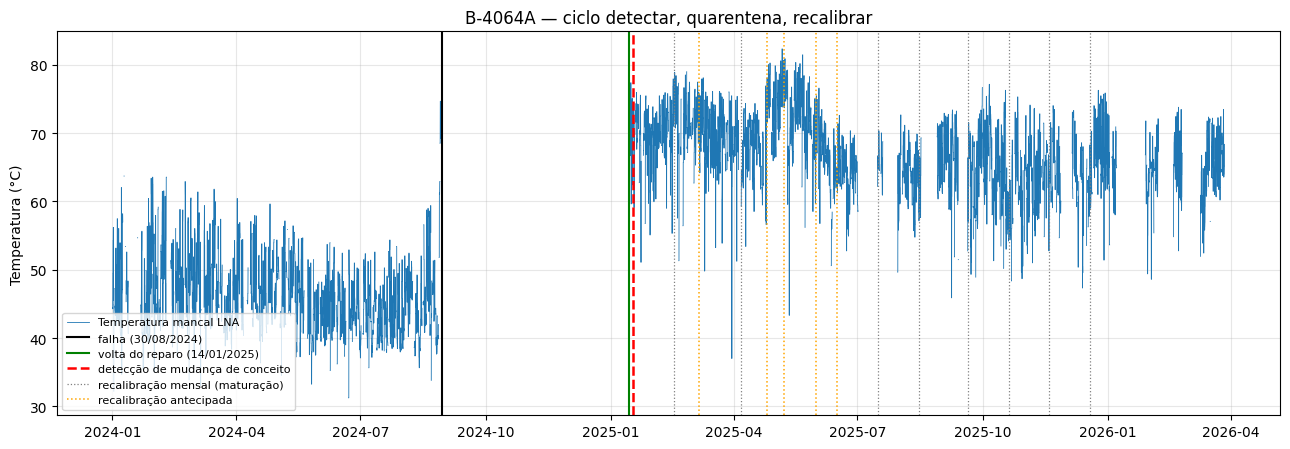

In [4]:
s = serie["Temperatura Bomba LNA"].asfreq("1h")
plt.figure(figsize=(13, 4.6))
plt.plot(s.index, s.values, linewidth=0.6, label="Temperatura mancal LNA")
plt.axvline(FALHA, color="black", linewidth=1.5, label="falha (30/08/2024)")
plt.axvline(VOLTA, color="green", linewidth=1.5, label="volta do reparo (14/01/2025)")
for i, t in enumerate(ev.loc[ev["tipo"] == "deteccao", "instante"]):
    plt.axvline(t, color="red", linewidth=1.8, linestyle="--", label="detecção de mudança de conceito" if i == 0 else None)
for i, t in enumerate(ev.loc[ev["tipo"] == "recalibracao", "instante"]):
    plt.axvline(t, color="gray", linewidth=0.9, linestyle=":", label="recalibração mensal (maturação)" if i == 0 else None)
for i, t in enumerate(ev.loc[ev["tipo"] == "recalibracao_antecipada", "instante"]):
    plt.axvline(t, color="orange", linewidth=1.1, linestyle=":", label="recalibração antecipada" if i == 0 else None)
plt.ylabel("Temperatura (°C)"); plt.title("B-4064A — ciclo detectar, quarentena, recalibrar")
plt.legend(loc="lower left", fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Figura 2 — o que o detector enxergou, fase por fase

Pior sensor do dia dividido pelo limiar vigente (acima de 1 = dia diferente da referência). A cada
recalibração o limiar muda, então a curva é sempre relativa à referência daquele momento.

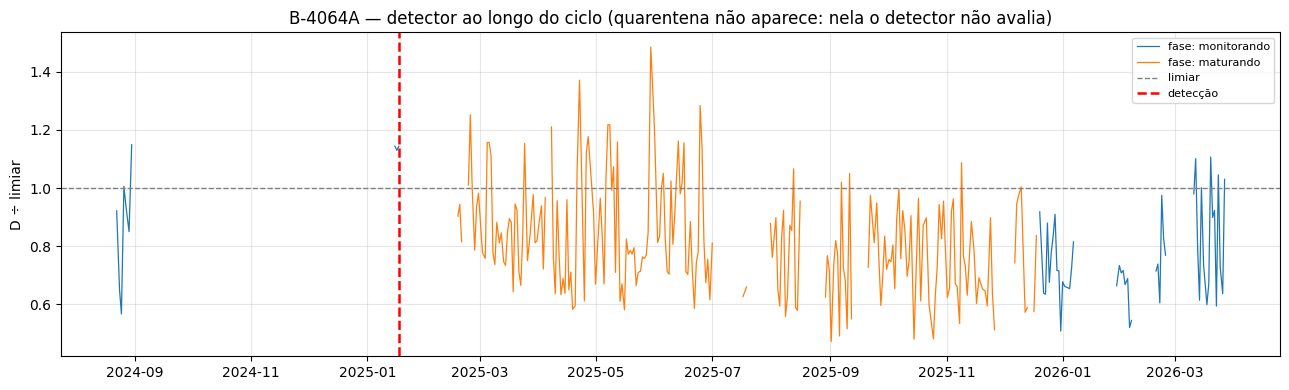

In [5]:
d = r.d_diario.copy()
buraco = d.index.to_series().diff() > pd.Timedelta(days=3)
d = pd.concat([d, pd.DataFrame({"d_razao": np.nan, "fase": None}, index=d.index[buraco] - pd.Timedelta(seconds=1))]).sort_index()
plt.figure(figsize=(13, 4))
for fase, cor in [("monitorando", "tab:blue"), ("maturando", "tab:orange")]:
    y = d["d_razao"].where(d["fase"] == fase)
    plt.plot(y.index, y.values, linewidth=0.9, color=cor, label=f"fase: {fase}")
plt.axhline(1, color="gray", linestyle="--", linewidth=1, label="limiar")
for i, t in enumerate(ev.loc[ev["tipo"] == "deteccao", "instante"]):
    plt.axvline(t, color="red", linewidth=1.8, linestyle="--", label="detecção" if i == 0 else None)
plt.ylabel("D ÷ limiar"); plt.title("B-4064A — detector ao longo do ciclo (quarentena não aparece: nela o detector não avalia)")
plt.legend(loc="upper right", fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Resumo

| | sem ciclo | com ciclo |
|---|---|---|
| disparos de 21/08/2024 a 27/03/2026 | **94** (a mesma mudança redetectada todo dia) | **1 detecção** + 8 recalibrações mensais + 5 antecipadas |
| rampa da falha (30/08/2024) | não dispara | não dispara |
| volta do reparo (14/01/2025) | detecta | detecta em **3,0 dias**, via Temperatura Bomba LNA |

**Leitura**
- A detecção é única e no ponto certo: o novo normal após o reparo, pelo sensor que mudou.
- As 5 recalibrações antecipadas (fevereiro a junho de 2025, todas por temperatura) mostram o novo normal
  ainda se acomodando: o mancal foi de ~70 °C para ~64 °C ao longo de 2025, e a referência de 1 a 5 meses
  ainda não cobria essa variação. Na simulação elas viram recalibração, e não conceito novo.
- Com a referência madura (~11 meses, a partir de dez/2025), não houve mais disparo até o fim dos dados.
  Em março/2026 alguns dias isolados passam do limiar, mas nenhum chega a 3 em 5.
- A falha continua sendo papel do modelo de anomalia: o detector não dispara na rampa de 2 dias.

**O que a simulação assume e a produção não pode assumir**
- Toda quarentena termina confirmando um novo normal. Em produção, essa confirmação é da operação, e uma
  degradação confirmada **não** recalibra (docs/politica_retreino.md).
- Recalibração antecipada absorve a variação que a referência curta não cobria. Se uma degradação lenta
  começasse nessa fase, ela também seria absorvida. Por isso, em produção, cada recalibração antecipada
  passa pela mesma confirmação.
- A recalibração aqui é só do detector. No ciclo completo, é nesse ponto que o modelo de anomalia também
  seria retreinado (drift/retrain.py), com a bateria de validação.